In [21]:
import re
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm.auto import tqdm

import albumentations as A
import segmentation_models_pytorch as smp

from sklearn.model_selection import train_test_split

In [22]:
ROOT = Path('.')
DATA_DIR = ROOT / 'data'
RANDOM_STATE = 42

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 8
NUM_EPOCHS = 25
LR = 3e-4
NUM_WORKERS = 2
CONFIDENCE_THRESHOLD = 20
CEMENT_IMAGE_BOOST = 4.0
WATER_IMAGE_BOOST = 3.0
CEMENT_PIXEL_BOOST = 2.0
WATER_PIXEL_BOOST = 3.0
CEMENT_CLASS_BOOST = 2.0
WATER_CLASS_BOOST = 1.5
DICE_WEIGHT = 0.3

NUM_CLASSES = 5
IGNORE_INDEX = 0
IN_CHANNELS = 17

BAND_MEANS = np.array([
    0.053736, 0.067704, 0.103031, 0.128712, 0.171945, 0.249336,
    0.281545, 0.291569, 0.306563, 0.311149, 0.292762, 0.211780,
], dtype=np.float32)
BAND_STDS = np.array([
    0.026682, 0.037134, 0.062856, 0.119531, 0.121726, 0.101212,
    0.101941, 0.102989, 0.101679, 0.100215, 0.167755, 0.175344,
], dtype=np.float32)

CLASS_NAMES = {
    0: 'Unknown',
    1: 'Greenery',
    2: 'Sand',
    3: 'Water',
    4: 'Cement',
}

print("DEVICE:", DEVICE)
print("IN_CHANNELS:", IN_CHANNELS)

DEVICE: cuda


In [23]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)

In [24]:
def extract_sample_id(path):
    match = re.search(r'(\d+)', Path(path).stem)
    if not match:
        raise ValueError(f'Could not extract numeric id from {path}')
    return match.group(1)


def build_pairs_dataframe(data_dir):
    img_paths = {extract_sample_id(p): p for p in (data_dir / 'imgs').glob('*.tif')}
    mask_paths = {extract_sample_id(p): p for p in (data_dir / 'masks').glob('*.tif')}

    if set(img_paths) != set(mask_paths):
        missing_imgs = sorted(set(mask_paths) - set(img_paths))
        missing_masks = sorted(set(img_paths) - set(mask_paths))
        raise ValueError(f'Unpaired files found. missing_imgs={missing_imgs[:5]} missing_masks={missing_masks[:5]}')

    rows = []
    for sample_id in sorted(img_paths, key=int):
        rows.append(
            {
                'sample_id': sample_id,
                'img_path': str(img_paths[sample_id]),
                'mask_path': str(mask_paths[sample_id]),
            }
        )

    return pd.DataFrame(rows)


def mask_summary(mask_path):
    with rasterio.open(mask_path) as src:
        mask = src.read(1)

    values, counts = np.unique(mask, return_counts=True)
    summary = {int(v): int(c) for v, c in zip(values, counts)}
    total = int(mask.size)

    return {
        'total_pixels': total,
        'has_water': int(3 in summary),
        'has_cement': int(4 in summary),
        'has_sand': int(2 in summary),
        **{f'count_{cls}': summary.get(cls, 0) for cls in range(5)},
    }


def build_metadata(data_dir):
    pairs = build_pairs_dataframe(data_dir)
    summaries = [mask_summary(path) for path in tqdm(pairs['mask_path'], desc='Scanning masks')]
    meta = pd.concat([pairs, pd.DataFrame(summaries)], axis=1)
    return meta


def build_strata(df):
    strata = np.where(
        (df['has_water'] == 1) & (df['has_cement'] == 1),
        'water_and_cement',
        np.where(
            df['has_water'] == 1,
            'water_only',
            np.where(df['has_cement'] == 1, 'cement_only', 'base')
        ),
    )

    strata = pd.Series(strata, index=df.index)
    counts = strata.value_counts()
    strata = strata.where(strata.map(counts) >= 2, 'base')
    return strata


def split_metadata(meta, random_state=RANDOM_STATE):
    meta = meta.copy()
    meta['stratum'] = build_strata(meta)

    train_df, temp_df = train_test_split(
        meta,
        test_size=0.30,
        random_state=random_state,
        stratify=meta['stratum'],
    )

    temp_df = temp_df.copy()
    temp_df['stratum'] = build_strata(temp_df)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=random_state,
        stratify=temp_df['stratum'],
    )

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def print_split_summary(name, df):
    print(f'[{name}] images: {len(df)}')
    for cls in range(5):
        pixels = int(df[f'count_{cls}'].sum())
        images = int((df[f'count_{cls}'] > 0).sum())
        print(f"  {CLASS_NAMES[cls]:<8} pixels={pixels:>9,} images={images:>3}")
    print('  strata:', df['stratum'].value_counts().to_dict())

In [25]:
meta = build_metadata(DATA_DIR)
train_meta, val_meta, test_meta = split_metadata(meta)

print_split_summary('train', train_meta)
print_split_summary('val', val_meta)
print_split_summary('test', test_meta)

Scanning masks: 100%|██████████| 210/210 [00:00<00:00, 752.74it/s]

[train] images: 147
  Unknown  pixels=    4,896 images= 32
  Greenery pixels=7,034,253 images=137
  Sand     pixels=2,034,749 images=116
  Water    pixels=  214,456 images= 25
  Cement   pixels=  345,438 images=107
  strata: {'cement_only': 86, 'base': 36, 'water_and_cement': 21, 'water_only': 4}
[val] images: 31
  Unknown  pixels=      529 images= 10
  Greenery pixels=1,417,652 images= 26
  Sand     pixels=  519,641 images= 26
  Water    pixels=   76,471 images=  6
  Cement   pixels=   17,323 images= 23
  strata: {'cement_only': 18, 'base': 7, 'water_and_cement': 5, 'water_only': 1}
[test] images: 32
  Unknown  pixels=      389 images=  9
  Greenery pixels=1,624,375 images= 30
  Sand     pixels=  373,650 images= 24
  Water    pixels=   20,362 images=  5
  Cement   pixels=   78,376 images= 23
  strata: {'cement_only': 19, 'base': 8, 'water_and_cement': 4, 'water_only': 1}


In [26]:
def preprocess_img(img_path, mask_path):
    with rasterio.open(img_path) as src:
        img = src.read().astype(np.float32)

    with rasterio.open(mask_path) as src:
        mask = src.read(1).astype(np.int64)
        if src.count >= 2:
            confidence = src.read(2).astype(np.float32)
            mask[confidence < CONFIDENCE_THRESHOLD] = IGNORE_INDEX

    img = np.clip(img, 0, 10000) / 10000.0

    blue = img[1]
    green = img[2]
    red = img[3]
    nir = img[7]
    swir1 = img[10]

    ndvi = (nir - red) / (nir + red + 1e-6)
    ndwi = (green - nir) / (green + nir + 1e-6)
    mndwi = (green - swir1) / (green + swir1 + 1e-6)
    ndbi = (swir1 - nir) / (swir1 + nir + 1e-6)
    bsi = ((swir1 + red) - (nir + blue)) / ((swir1 + red) + (nir + blue) + 1e-6)

    img = (img - BAND_MEANS[:, None, None]) / BAND_STDS[:, None, None]
    img = np.concatenate(
        [
            img,
            ndvi[None, ...],
            ndwi[None, ...],
            mndwi[None, ...],
            ndbi[None, ...],
            bsi[None, ...],
        ],
        axis=0,
    ).astype(np.float32)

    return img, mask

In [27]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

val_transform = A.Compose([])

In [28]:
class LandCoverSegDataset(Dataset):
    def __init__(self, split_df, transform=None):
        self.records = split_df[['img_path', 'mask_path']].to_dict('records')
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        row = self.records[idx]
        img, mask = preprocess_img(row['img_path'], row['mask_path'])  # img: (C,H,W)

        img_hwc = np.transpose(img, (1, 2, 0))  # for albumentations

        if self.transform is not None:
            out = self.transform(image=img_hwc, mask=mask)
            img_hwc = out['image']
            mask = out['mask']

        img = np.transpose(img_hwc, (2, 0, 1)).astype(np.float32)
        mask = mask.astype(np.int64)

        return torch.from_numpy(img), torch.from_numpy(mask)

In [29]:
train_ds = LandCoverSegDataset(train_meta, transform=train_transform)
val_ds   = LandCoverSegDataset(val_meta, transform=val_transform)
test_ds  = LandCoverSegDataset(test_meta, transform=val_transform)

train_sample_weights = (
    1.0
    + CEMENT_IMAGE_BOOST * train_meta['has_cement'].to_numpy(dtype=np.float32)
    + WATER_IMAGE_BOOST * train_meta['has_water'].to_numpy(dtype=np.float32)
)
train_sample_weights += CEMENT_PIXEL_BOOST * (
    train_meta['count_4'].to_numpy(dtype=np.float32)
    / max(float(train_meta['count_4'].max()), 1.0)
)
train_sample_weights += WATER_PIXEL_BOOST * (
    train_meta['count_3'].to_numpy(dtype=np.float32)
    / max(float(train_meta['count_3'].max()), 1.0)
)

train_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(train_sample_weights, dtype=torch.double),
    num_samples=len(train_ds),
    replacement=True,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print(len(train_ds), len(val_ds), len(test_ds))
print('Train images with cement:', int(train_meta['has_cement'].sum()))
print('Train images with water :', int(train_meta['has_water'].sum()))
print('Sampler weight range:', float(train_sample_weights.min()), '->', float(train_sample_weights.max()))

147 31 32
Train images with cement: 107
Sampler weight range: 1.0 -> 7.910214900970459


In [30]:
imgs, masks = next(iter(train_loader))
print("imgs :", imgs.shape)   # [B, 17, H, W]
print("masks:", masks.shape)  # [B, H, W]
print("mask unique:", torch.unique(masks))

imgs : torch.Size([8, 12, 256, 256])
masks: torch.Size([8, 256, 256])
mask unique: tensor([0, 1, 2, 3, 4])


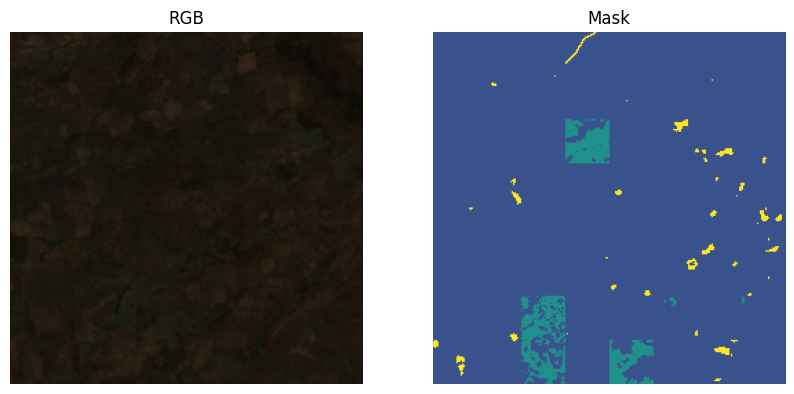

In [38]:
def show_sample(img, mask, pred=None):
    raw_rgb = img[[3, 2, 1]]
    raw_rgb = raw_rgb * BAND_STDS[[3, 2, 1], None, None] + BAND_MEANS[[3, 2, 1], None, None]
    rgb = np.transpose(raw_rgb, (1, 2, 0))
    rgb = np.clip(rgb * 3.0, 0, 1)

    ncols = 3 if pred is not None else 2
    plt.figure(figsize=(5 * ncols, 5))

    plt.subplot(1, ncols, 1)
    plt.imshow(rgb)
    plt.title("RGB")
    plt.axis("off")

    plt.subplot(1, ncols, 2)
    plt.imshow(mask, vmin=0, vmax=4)
    plt.title("Mask")
    plt.axis("off")

    if pred is not None:
        plt.subplot(1, ncols, 3)
        plt.imshow(pred, vmin=0, vmax=4)
        plt.title("Prediction")
        plt.axis("off")

    plt.show()


img0, mask0 = train_ds[80]
show_sample(img0.numpy(), mask0.numpy())

In [12]:
model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=IN_CHANNELS,
    classes=NUM_CLASSES,
)

model = model.to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f} M")

Parameters: 14.36 M


In [13]:
class_pixel_counts = np.array([
    train_meta['count_1'].sum(),
    train_meta['count_2'].sum(),
    train_meta['count_3'].sum(),
    train_meta['count_4'].sum(),
], dtype=np.float32)
class_weights = np.sqrt(class_pixel_counts.max() / np.maximum(class_pixel_counts, 1.0))
class_weights[2] *= WATER_CLASS_BOOST
class_weights[-1] *= CEMENT_CLASS_BOOST
ce_weights = torch.tensor([0.0, *class_weights.tolist()], dtype=torch.float32, device=DEVICE)

ce_loss = nn.CrossEntropyLoss(weight=ce_weights, ignore_index=IGNORE_INDEX)
dice_loss = smp.losses.DiceLoss(
    mode='multiclass',
    classes=[1, 2, 3, 4],
    from_logits=True,
    ignore_index=IGNORE_INDEX,
)

def criterion(logits, masks):
    ce = ce_loss(logits, masks)
    dice = dice_loss(logits, masks)
    return ce + DICE_WEIGHT * dice

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
print('Class weights:', {CLASS_NAMES[i + 1]: round(float(w), 4) for i, w in enumerate(class_weights)})

Class weights: {'Greenery': 1.0, 'Sand': 1.6378, 'Water': 7.16, 'Cement': 14.4226}


In [14]:
def fast_confusion_matrix(y_true, y_pred, num_classes=5, ignore_index=0):
    mask = y_true != ignore_index
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true.reshape(-1), y_pred.reshape(-1)):
        cm[t, p] += 1
    return cm


def per_class_iou_from_cm(cm, classes=(1, 2, 3, 4)):
    ious = {}
    for c in classes:
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        denom = tp + fp + fn
        ious[c] = tp / denom if denom > 0 else 0.0
    return ious


def mean_iou_from_cm(cm, classes=(1, 2, 3, 4)):
    ious = per_class_iou_from_cm(cm, classes)
    return float(np.mean(list(ious.values()))), ious

In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for imgs, masks in tqdm(loader, desc="Train", leave=False):
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    return running_loss / len(loader.dataset)

In [16]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    total_cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

    for imgs, masks in tqdm(loader, desc="Eval", leave=False):
        imgs = imgs.to(device)
        masks = masks.to(device)

        logits = model(imgs)
        loss = criterion(logits, masks)
        preds = torch.argmax(logits, dim=1)

        running_loss += loss.item() * imgs.size(0)

        cm = fast_confusion_matrix(
            masks.cpu().numpy(),
            preds.cpu().numpy(),
            num_classes=NUM_CLASSES,
            ignore_index=IGNORE_INDEX,
        )
        total_cm += cm

    avg_loss = running_loss / len(loader.dataset)
    miou, per_class_iou = mean_iou_from_cm(total_cm, classes=(1, 2, 3, 4))
    return avg_loss, miou, per_class_iou, total_cm

In [17]:
best_val_miou = -1.0
best_path = "best_unet_12band.pth"

history = {
    "train_loss": [],
    "val_loss": [],
    "val_miou": [],
}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_miou, val_ious, val_cm = evaluate(model, val_loader, criterion, DEVICE)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_miou"].append(val_miou)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss  : {val_loss:.4f}")
    print(f"  Val mIoU  : {val_miou:.4f}")
    print("  Val IoU   :", {CLASS_NAMES[k]: round(v, 4) for k, v in val_ious.items()})

    if val_miou > best_val_miou:
        best_val_miou = val_miou
        torch.save(model.state_dict(), best_path)
        print("  Saved best model.")

Epoch 01/25
  Train Loss: 1.4464
  Val Loss  : 1.6273
  Val mIoU  : 0.2816
  Val IoU   : {'Greenery': np.float64(0.4712), 'Sand': np.float64(0.5972), 'Water': np.float64(0.0), 'Cement': np.float64(0.0578)}
  Saved best model.


Epoch 02/25
  Train Loss: 1.0729
  Val Loss  : 1.1334
  Val mIoU  : 0.3540
  Val IoU   : {'Greenery': np.float64(0.4497), 'Sand': np.float64(0.5273), 'Water': np.float64(0.3846), 'Cement': np.float64(0.0546)}
  Saved best model.


Epoch 03/25
  Train Loss: 1.0116
  Val Loss  : 1.2937
  Val mIoU  : 0.3121
  Val IoU   : {'Greenery': np.float64(0.2965), 'Sand': np.float64(0.6937), 'Water': np.float64(0.2255), 'Cement': np.float64(0.0327)}


Epoch 04/25
  Train Loss: 0.9696
  Val Loss  : 1.5783
  Val mIoU  : 0.3294
  Val IoU   : {'Greenery': np.float64(0.9204), 'Sand': np.float64(0.1474), 'Water': np.float64(0.1327), 'Cement': np.float64(0.1171)}


Epoch 05/25
  Train Loss: 0.8081
  Val Loss  : 1.1598
  Val mIoU  : 0.3623
  Val IoU   : {'Greenery': np.float64(0.9436), 'Sand': np.float64(0.2132), 'Water': np.float64(0.1555), 'Cement': np.float64(0.1367)}
  Saved best model.


...

Epoch 14/25
  Train Loss: 0.7609
  Val Loss  : 0.7117
  Val mIoU  : 0.5983
  Val IoU   : {'Greenery': np.float64(0.889), 'Sand': np.float64(0.6931), 'Water': np.float64(0.6902), 'Cement': np.float64(0.1211)}


Epoch 15/25
  Train Loss: 0.6401
  Val Loss  : 1.0698
  Val mIoU  : 0.5093
  Val IoU   : {'Greenery': np.float64(0.5027), 'Sand': np.float64(0.7473), 'Water': np.float64(0.7509), 'Cement': np.float64(0.0362)}


Epoch 16/25
  Train Loss: 0.7272
  Val Loss  : 0.8331
  Val mIoU  : 0.5056
  Val IoU   : {'Greenery': np.float64(0.4346), 'Sand': np.float64(0.819), 'Water': np.float64(0.7332), 'Cement': np.float64(0.0358)}


Epoch 17/25
  Train Loss: 0.6605
  Val Loss  : 0.9136
  Val mIoU  : 0.5008
  Val IoU   : {'Greenery': np.float64(0.5235), 'Sand': np.float64(0.6695), 'Water': np.float64(0.7489), 'Cement': np.float64(0.0612)}


KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(history["val_miou"], label="val_miou")
plt.legend()
plt.title("Val mIoU")

plt.show()

In [ ]:
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()
print("Best model loaded.")

In [ ]:
val_loss, val_miou, val_ious, val_cm = evaluate(model, val_loader, criterion, DEVICE)

print("Validation loss:", val_loss)
print("Validation mIoU:", val_miou)
print("Validation per-class IoU:")
for k, v in val_ious.items():
    print(f"  {CLASS_NAMES[k]}: {v:.4f}")

print("\nValidation confusion matrix:")
print(val_cm)

In [ ]:
test_loss, test_miou, test_ious, test_cm = evaluate(model, test_loader, criterion, DEVICE)

print("Test loss:", test_loss)
print("Test mIoU:", test_miou)
print("Test per-class IoU:")
for k, v in test_ious.items():
    print(f"  {CLASS_NAMES[k]}: {v:.4f}")

print("\nTest confusion matrix:")
print(test_cm)

In [ ]:
@torch.no_grad()
def predict_mask(model, img_tensor, device):
    model.eval()
    x = img_tensor.unsqueeze(0).to(device)
    logits = model(x)
    pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
    return pred


for i in range(min(3, len(val_ds))):
    img, mask = val_ds[i]
    pred = predict_mask(model, img, DEVICE)
    show_sample(img.numpy(), mask.numpy(), pred)

In [ ]:
print("Train images:", len(train_meta))
print("Val images  :", len(val_meta))
print("Test images :", len(test_meta))
print("Best val mIoU:", best_val_miou)